In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import pyKriging
import scipy
from matplotlib.path import Path
from scipy.integrate import nquad
import csv
import time
import math

In [2]:
# 画图默认设置
dpi=300
plt.rcParams['axes.unicode_minus'] = False#使用上标小标小一字号
plt.rcParams['font.sans-serif']=['Times New Roman']
    #设置全局字体，可选择需要的字体替换掉‘Times New Roman’
    #使用黑体'SimHei'作为全局字体，可以显示中文
    #plt.rcParams['font.sans-serif']=['SimHei']
font1={'family': 'Times New Roman', 'weight': 'light', 'size': 12}#设置字体模板，
    #wight为字体的粗细，可选 ‘normal\bold\light’等
    #size为字体大小
# plt.savefig('./XXX.tif')

In [3]:
def create_interpolator(matrix, fan):
    def Inter(target_x, target_y):
        # 将实际坐标转换为索引值
        target_x_idx = target_x / 30.0
        target_y_idx = target_y / 30.0
        fan_idx = fan / 30.0
        
        if target_x_idx < fan_idx:
            x_index_st = 0
        else:
            x_index_st = int(np.round(target_x_idx - fan_idx))
            
        if target_y_idx < fan_idx:
            y_index_st = 0
        else:
            y_index_st = int(np.round(target_y_idx - fan_idx))
        
        [dm, dn] = matrix.shape
        
        x_index_end = int(np.round(target_x_idx + fan_idx + 1))
        if x_index_end > dm:
            x_index_end = dm
            x_index_st = dm - 2 * int(fan_idx) - 1
            
        y_index_end = int(np.round(target_y_idx + fan_idx + 1))
        if y_index_end > dn:
            y_index_end = dn
            y_index_st = dn - 2 * int(fan_idx) - 1

        z_matrix = matrix[x_index_st:x_index_end, y_index_st:y_index_end]
        
        target_x_relative = target_x_idx - x_index_st
        target_y_relative = target_y_idx - y_index_st
        
        if target_x_relative.is_integer() and target_y_relative.is_integer():
            target_x_relative = int(target_x_relative)
            target_y_relative = int(target_y_relative)
            if 0 <= target_x_relative < z_matrix.shape[1] and 0 <= target_y_relative < z_matrix.shape[0]:
                existing_value = z_matrix[target_y_relative, target_x_relative]
                return existing_value, existing_value

        # 生成 x, y 坐标网格
        x_coords = np.arange(z_matrix.shape[0])
        y_coords = np.arange(z_matrix.shape[1])
        
        # 检查 z_matrix 的大小并选择合适的插值方法
        # if z_matrix.shape[0] >= 4 and z_matrix.shape[1] >= 4:
        #     method = 'cubic'
        # else:
        #     method = 'linear'
        method = 'linear'
        # 使用 RegularGridInterpolator 进行插值
        interpolating_function = scipy.interpolate.RegularGridInterpolator((x_coords, y_coords), z_matrix, method=method)
        target_val = interpolating_function((target_x_relative, target_y_relative))

        return target_val, z_matrix[int(np.round(target_x_relative)), int(np.round(target_y_relative))]
    
    return Inter


def Inter_Kring(target_x,target_y,matrix,fan,Ktype='power'):
    # fan=3
    target_x = np.array([target_x])
    target_y = np.array([target_y])
    fanwei=np.array([fan])

    
    if target_x<fan:
        x_index_st = [0]
    else:
        x_index_st=(target_x.round()-fanwei).astype(int)
        
    if target_y<fan:
        y_index_st = [0]
    else:
        y_index_st=(target_y.round()-fanwei).astype(int)
    
    [dm,dn]=matrix.shape
    
    x_index_end=(target_x.round()+fanwei+1).astype(int)
    if x_index_end[0]>dm:
        x_index_end=[dm]
        x_index_st=[dm-2*fan-1]
        
    y_index_end=(target_y.round()+fanwei+1).astype(int)
    if y_index_end[0]>dn:
        y_index_end=[dn]
        y_index_st=[dn-2*fan-1]
    
    z_matrix = []
    z_matrix = matrix[x_index_st[0]:x_index_end[0], y_index_st[0]:y_index_end[0]]

    #plot the result
    # vmin = z_matrix.min()
    # vmax = z_matrix.max()
    # plt.imshow(z_matrix,cmap='coolwarm', aspect='auto', origin='lower')
    # plt.colorbar()
    # plt.scatter(target_x.round()-x_index_st,target_y.round()-y_index_st,color='black', s=50, marker='o')
    x_coords, y_coords = np.meshgrid(np.arange(z_matrix.shape[1]), np.arange(z_matrix.shape[0]))
    
    # 将 x, y 坐标和 z 值展平成一维数组
    x = x_coords.ravel()
    y = y_coords.ravel()
    z = z_matrix.ravel()
    
    UK_liner= pykrige.uk.UniversalKriging(x, y, z, variogram_model=Ktype,drift_terms=['regional_linear'])
    # UK_liner= pykrige.OrdinaryKriging(x, y, z, variogram_model='linear')
    # drift_terms (list of strings, optional) – List of drift terms to include in universal kriging. 
    # Supported drift terms are currently ‘regional_linear’, ‘point_log’, ‘external_Z’, ‘specified’, and ‘functional’.
    
    # power 449.1830050580911
    # linear 449.1894719199214
    # gaussian 449.2789468277389
    # spherical 449.1875679990333
    # exponential 449.19770676261953
    # hole-effect very ridiculous
    
    
    # 插值目标点
    z_pred, ss = UK_liner.execute('points', target_x-x_index_st, target_y-y_index_st)
    # f = scipy.interpolate.interp2d(x, y, z_matrix, kind='linear')
    # target_val = f(target_x, target_y)
    # print(target_val[0])
    print(z_matrix[(target_x.round()-x_index_st).astype(int),(target_y.round()-y_index_st).astype(int)])
    print("插值结果:", z_pred[0])
    print("预测值的方差:", ss[0])
    cc = UK_liner.get_epsilon_residuals()
    UK_liner.display_variogram_model()
    UK_liner.plot_epsilon_residuals()
    UK_liner.print_statistics()
    plt.imshow(z_matrix,cmap='coolwarm', aspect='auto', origin='lower')
    plt.colorbar()
    plt.scatter(target_x-x_index_st, target_y-y_index_st, 
                c=z_pred,  # 根据散点的位置取 z_matrix 的值作为颜色
                cmap='coolwarm', s=20, marker='*', vmin=vmin, vmax=vmax)
    return z_pred[0],z_matrix[(target_x.round()-x_index_st).astype(int),(target_y.round()-y_index_st).astype(int)]

In [4]:
def calculate_volume(p1, p2, p3 , rho):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    S = 0.5 * abs((x1 * y2 - x2 * y1) + (x2 * y3 - x3 * y2) + (x3 * y1 - x1 * y3))
    E = (S / 12) * ((x1 - x2)**2 + (y1 - y2)**2 + (x3 - x2)**2 + (y3 - y2)**2 + (x1 - x3)**2 + (y1 - y3)**2)
    volum = E*rho(p1, p2, p3)
    return volum

In [5]:
def Eopt(nodes,rho):
    points = nodes[:,:2]
    tri = scipy.spatial.Delaunay(points)
    Eopti = []

    ninter = tri.simplices.shape[0]

    for i,index in enumerate(tri.simplices):
        [p1,p2,p3]=points[index]
        Eopti.append(calculate_volume(p1,p2,p3,rho))
        # print(f"第 {i+1} 次已完成")
    Eopts = sum(Eopti)
    return Eopts
# def Eopt(nodes):
#     return nodes[1]+nodes[2]

In [6]:
# def create_rho(points):
#     mtri = scipy.spatial.Delaunay(points)
    
#     def triangle_area_3d(p1, p2, p3):
#         u = np.array(p2) - np.array(p1)
#         v = np.array(p3) - np.array(p1)
#         cross_product = np.cross(u, v)
#         area = 0.5 * np.linalg.norm(cross_product)
#         return area

#     def projection_area(p1, p2, p3):
#         p1_proj = [p1[0], p1[1], 0]
#         p2_proj = [p2[0], p2[1], 0]
#         p3_proj = [p3[0], p3[1], 0]
#         return triangle_area(p1_proj, p2_proj, p3_proj)

#     def rho(p1, p2, p3):
#         [px,py] = circumcenter(p1, p2, p3)
#         bar = [px, py]
#         simplex = mtri.find_simplex(bar)
#         if simplex == -1:
#             return 0  # 如果巴比可心不在任何三角面片内
            
#         vertices = mtri.simplices[simplex]
#         v0 = [points[vertices[0]][0], points[vertices[0]][1], datafinal[vertices[0] // n_row, vertices[0] % n_row]]
#         v1 = [points[vertices[1]][0], points[vertices[1]][1], datafinal[vertices[1] // n_row, vertices[1] % n_row]]
#         v2 = [points[vertices[2]][0], points[vertices[2]][1], datafinal[vertices[2] // n_row, vertices[2] % n_row]]
        
#         area_3d = triangle_area_3d(v0, v1, v2)
#         area_proj = triangle_area_3d(v0[:2] + [0], v1[:2] + [0], v2[:2] + [0])
#         return 10*area_3d / area_proj if area_proj != 0 else 0
#     return rho
    
def create_rho(Inter):
    def triangle_area(p1, p2, p3):
        u = np.array(p2) - np.array(p1)
        v = np.array(p3) - np.array(p1)
        cross_product = np.cross(u, v)
        area = 0.5 * np.linalg.norm(cross_product)
        return area

    def projection_area(p1, p2, p3):
        p1_proj = [p1[0], p1[1], 0]
        p2_proj = [p2[0], p2[1], 0]
        p3_proj = [p3[0], p3[1], 0]
        return triangle_area(p1_proj, p2_proj, p3_proj)

    def rho(p1, p2, p3):
        p1 = np.append(p1, Inter(p1[0], p1[1])[0])
        p2 = np.append(p2, Inter(p2[0], p2[1])[0])
        p3 = np.append(p3, Inter(p3[0], p3[1])[0])
        area_3d = triangle_area(p1, p2, p3)
        area_proj = projection_area(p1, p2, p3)
        if area_proj == 0:
            return np.inf  # 避免除以零
        density = area_3d / area_proj
        return (density)*10
    return rho


In [7]:
def circumcenter(A, B, C):
    """ 计算三角形的巴比可心坐标 """
    D = 2 * (A[0] * (B[1] - C[1]) + B[0] * (C[1] - A[1]) + C[0] * (A[1] - B[1]))
    Ux = ((A[0]**2 + A[1]**2) * (B[1] - C[1]) + (B[0]**2 + B[1]**2) * (C[1] - A[1]) + (C[0]**2 + C[1]**2) * (A[1] - B[1])) / D
    Uy = ((A[0]**2 + A[1]**2) * (C[0] - B[0]) + (B[0]**2 + B[1]**2) * (A[0] - C[0]) + (C[0]**2 + C[1]**2) * (B[0] - A[0])) / D
    return np.array([Ux, Uy])

def triangle_area(A, B, C):
    """ 计算三角形面积 """
    return abs((A[0] * (B[1] - C[1]) + B[0] * (C[1] - A[1]) + C[0] * (A[1] - B[1])) / 2)

In [8]:
def find_all_one_ring_neighbors(nodes):
    # 初始化每个点的邻域集合
    neighbors = {i: set() for i in range(len(tri.points))}
    # 遍历所有的三角形
    for simplex in tri.simplices:
        for i in simplex:
            # 将三角形中的其他点添加到当前点的邻域集合
            neighbors[i].update(simplex)
    # 从每个集合中移除点自身
    for i in range(len(tri.points)):
        neighbors[i].discard(i)
    return neighbors
    
def find_all_triangles_in_one_ring(tri):
    # 初始化每个点的三角形列表
    point_triangles = {i: [] for i in range(len(tri.points))}
    # 遍历所有的三角形
    for simplex_index, simplex in enumerate(tri.simplices):
        for vertex in simplex:
            # 将三角形索引添加到点的三角形列表中
            point_triangles[vertex].append(simplex_index)
    return point_triangles

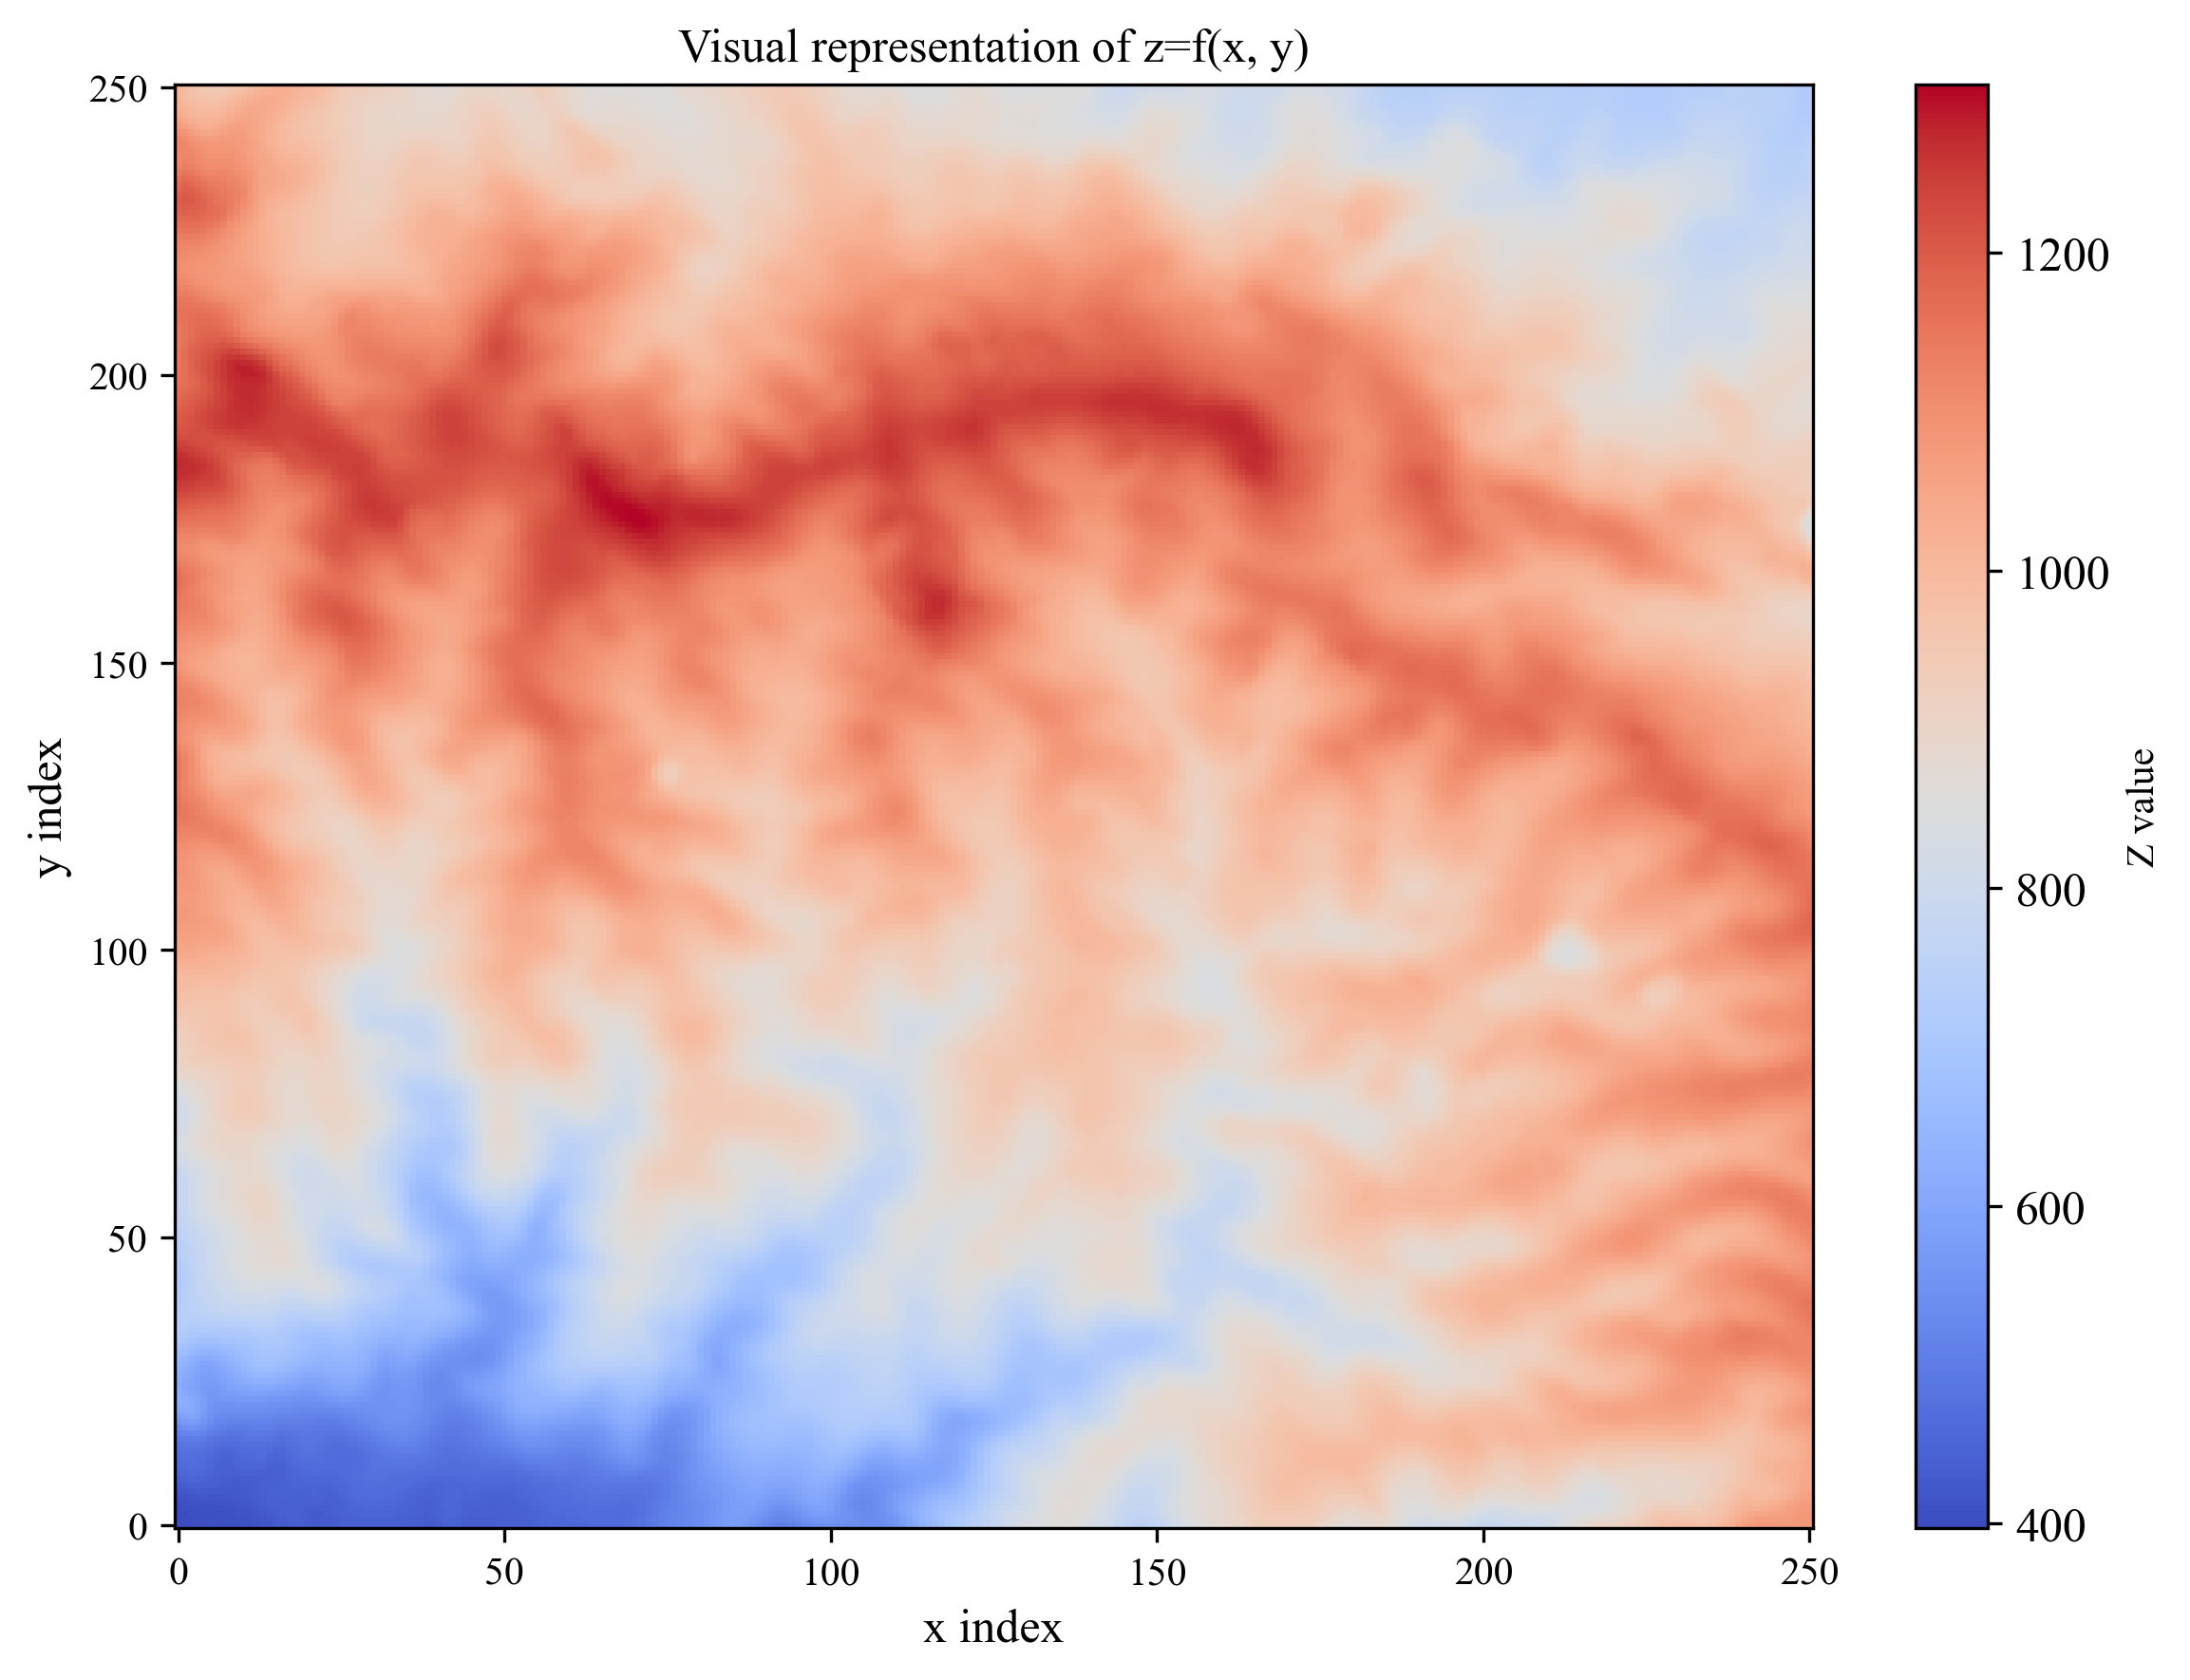

In [9]:
# 导入图像（data,size=251*251）
file_path = '1test.xlsx'
df = pd.read_excel(file_path, skiprows=5)
data = df.to_numpy()


plt.figure(num=1,figsize=(8, 6),dpi=dpi)
plt.imshow(data, cmap='coolwarm', aspect='auto', origin='lower')
plt.colorbar(label='Z value').ax.tick_params(labelsize=font1['size']) # 显示颜色条
plt.title('Visual representation of z=f(x, y)', fontdict=font1)
plt.xlabel('x index', fontdict=font1)
plt.ylabel('y index',fontdict=font1)
plt.title('Visual representation of z=f(x, y)',fontdict=font1)
plt.ticklabel_format(axis='both',style='sci')
plt.tight_layout(rect=(0,0,1,1))#rect=[left,bottom,right,top]
plt.show()

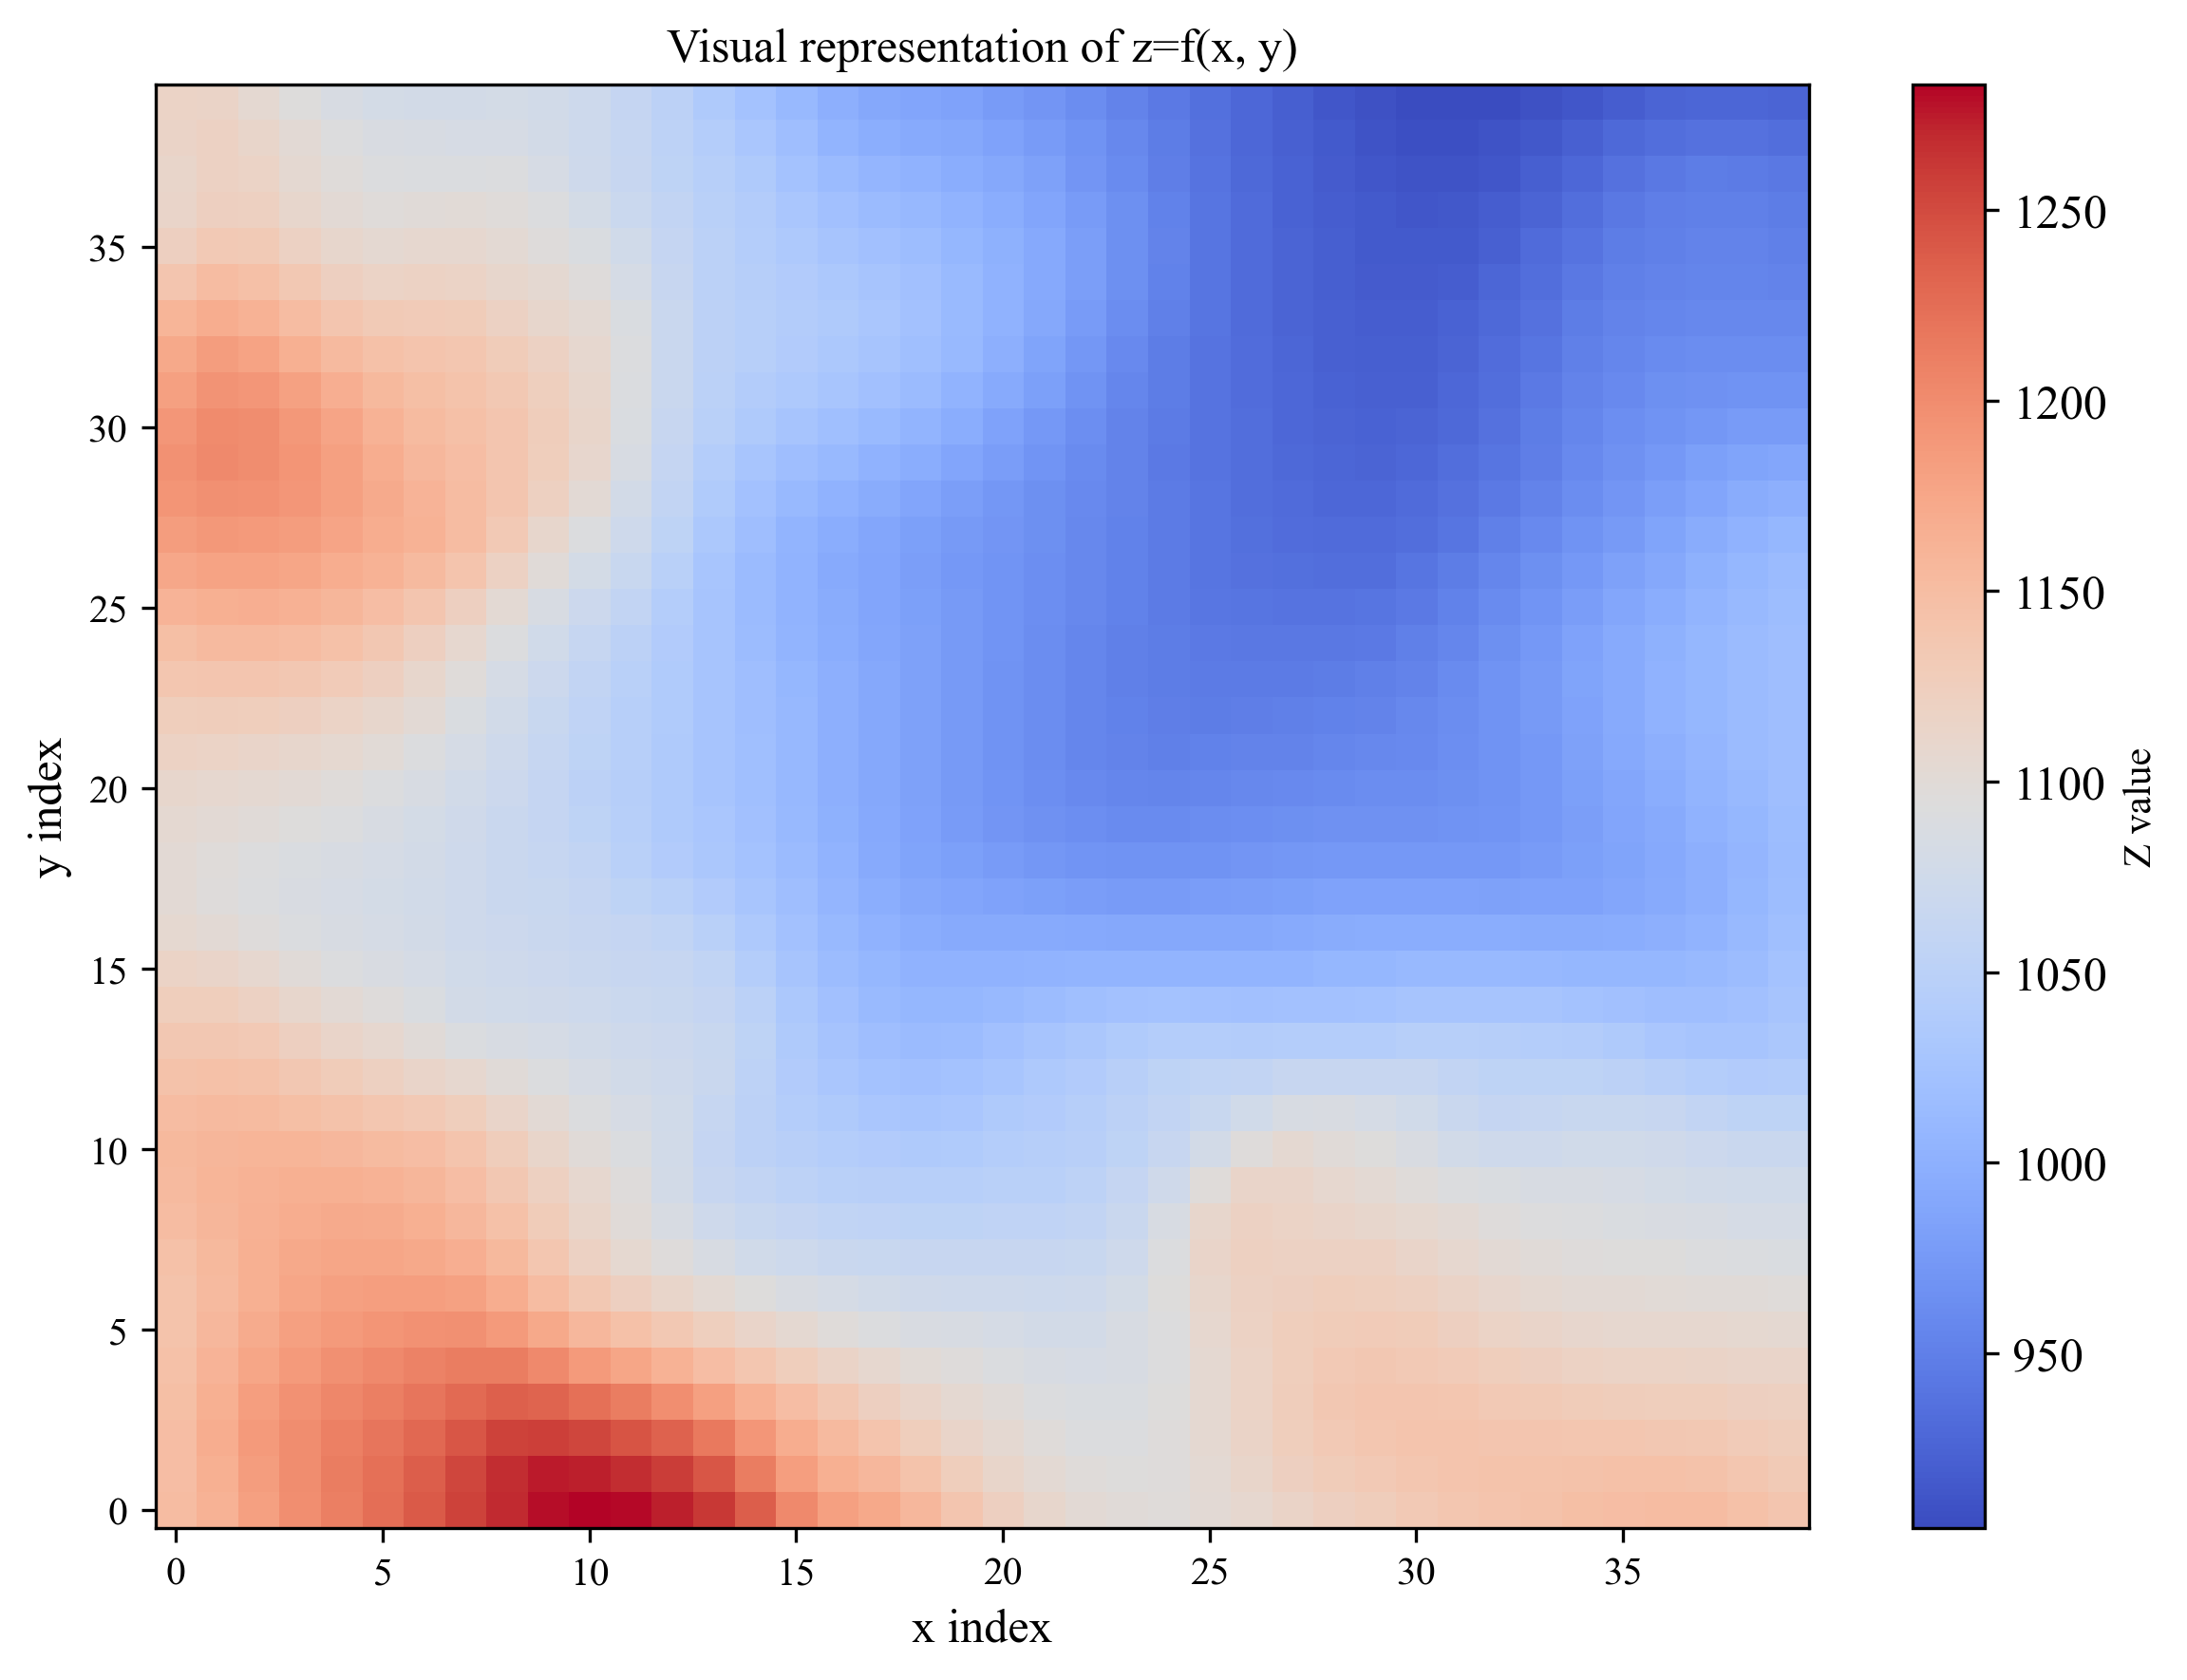

In [10]:
#导入测试图像（data_wt,size=50*50）
data_wt = data[0:40,0:40]
# data_wt = data
plt.figure(num=2,figsize=(8, 6),dpi=dpi)
plt.imshow(data_wt, cmap='coolwarm', aspect='auto', origin='lower')
plt.colorbar(label='Z value').ax.tick_params(labelsize=font1['size']) # 显示颜色条
plt.title('Visual representation of z=f(x, y)', fontdict=font1)
plt.xlabel('x index', fontdict=font1)
plt.ylabel('y index',fontdict=font1)
plt.title('Visual representation of z=f(x, y)',fontdict=font1)
plt.ticklabel_format(axis='both',style='sci')
plt.tight_layout(rect=(0,0,1,1))#rect=[left,bottom,right,top]
plt.show()

<Figure size 1920x1440 with 0 Axes>

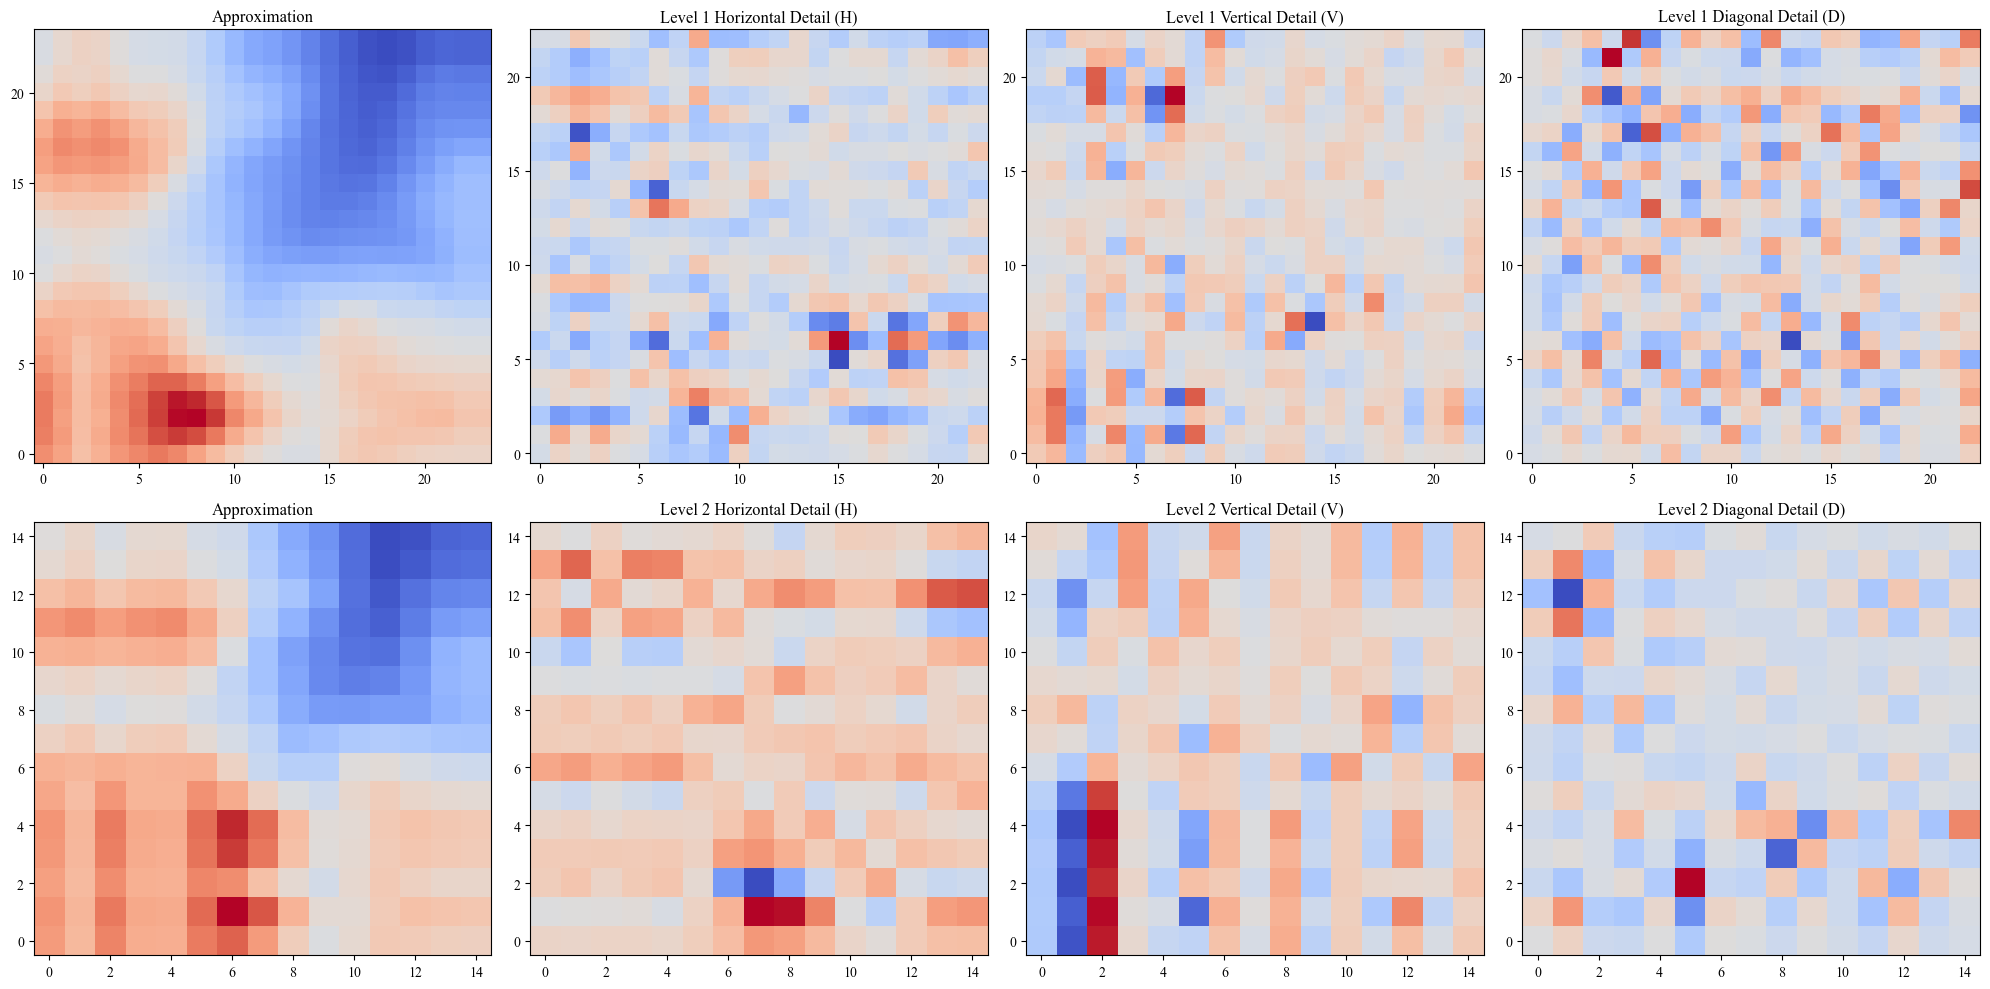

In [11]:
#完成小波分解，计算每一层的coeffi[i]-0-ARRARY,1-TUPLE-1*3
ceng=2
coeffs = pywt.wavedec2(data_wt, 'db4', level=ceng)
coeffi = []
coeffi.append([coeffs[0], coeffs[1]])
for i in range(ceng-1):
    A_i = pywt.waverec2(coeffi[i],'db4')
    coeffi.append([A_i,coeffs[i+2]])

data_rec = pywt.waverec2(coeffi[-1],'db4')

# 准备绘制
plt.figure(num=3,dpi=dpi)
fig, axs = plt.subplots(ceng, 4, figsize=(20, 5*ceng))
titles = ['Approximation (A)', 'Horizontal Detail (H)', 'Vertical Detail (V)', 'Diagonal Detail (D)']



# 绘制近似系数和细节系数
for i in range(ceng):
    axs[ceng-1-i, 0].imshow(coeffi[i][0], cmap='coolwarm', aspect='auto', origin='lower')
    axs[ceng-1-i, 0].set_title('Approximation', fontdict=font1)

    cH, cV, cD = coeffi[i][1][0], coeffi[i][1][1], coeffi[i][1][2]  # 从第二项开始每一项是一个包含三个细节系数的元组
    axs[ceng-1-i, 1].imshow(cH , cmap='coolwarm', aspect='auto', origin='lower')  # 显示当前层的近似系数
    axs[ceng-1-i, 1].set_title(f'Level {ceng-i} {titles[1]}', fontdict=font1)
  
        
    axs[ceng-1-i, 2].imshow(cV,  cmap='coolwarm', aspect='auto', origin='lower')
    axs[ceng-1-i, 2].set_title(f'Level {ceng-i} {titles[2]}', fontdict=font1)
   
        
    axs[ceng-1-i, 3].imshow(cD,  cmap='coolwarm', aspect='auto', origin='lower')
    axs[ceng-1-i, 3].set_title(f'Level {ceng-i} {titles[3]}',fontdict=font1)

plt.ticklabel_format(axis='both',style='sci')
plt.tight_layout(rect=(0,0,1,1))#rect=[left,bottom,right,top]
plt.show()

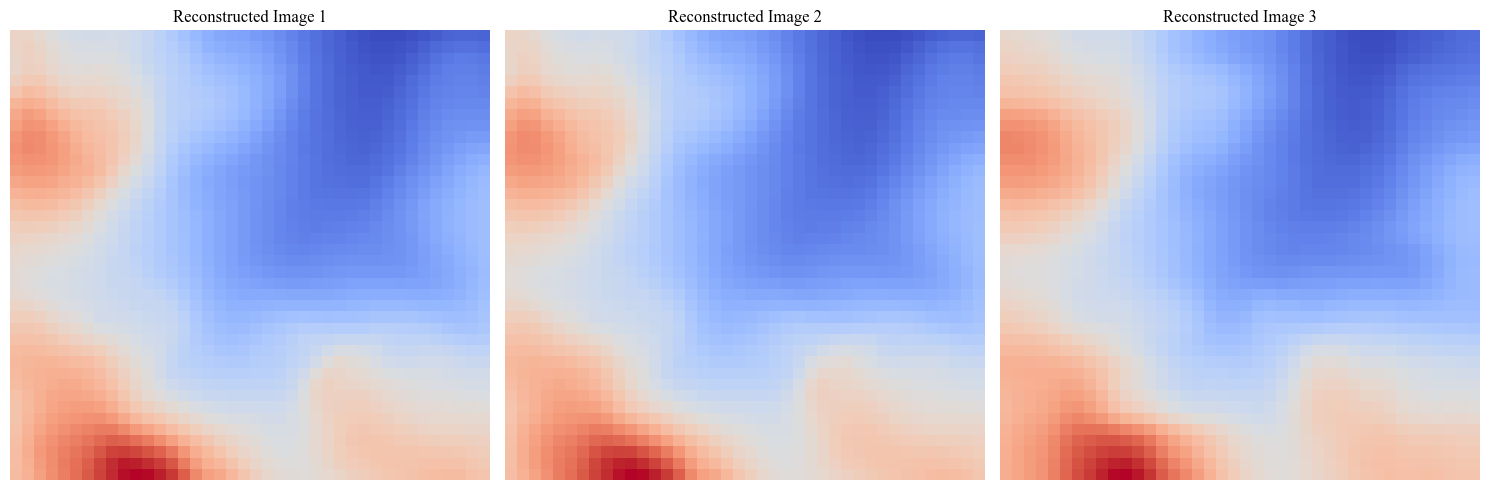

In [12]:
# 设置趋势面使用的分解层级  传递变量ceng ， coeffi 分解层数越高，分辨率越低，从分辨率低的地方置零
coeff_soomth = []
coeff_soomth = coeffi
data_soomth=[]
data_soomth.append(data_wt)
for j in range(ceng):
    new_coeffs = []
    new_coeffs.append(coeff_soomth[0][0])
    for i in range(ceng):
        if i>=ceng-j-1:
            ch=np.zeros_like(coeff_soomth[i][1][0]);
            new_coeffs.append([ch,ch,ch])
        else:
            new_coeffs.append([coeff_soomth[i][1][0],coeff_soomth[i][1][1],coeff_soomth[i][1][2]])
    data_soomth.append(pywt.waverec2(new_coeffs,'db4'))




n = len(data_soomth)  # 获取重构图像的数量
cols = n  # 将每个图像放在其列中
rows = 1  # 所有图像在一行中

# 创建一个足够大的图形来容纳所有子图
fig, axs = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))

if n == 1:
    axs.imshow(data_soomth[0], cmap='coolwarm', aspect='auto', origin='lower')
    axs.set_title('Reconstructed Image 1')
    axs.axis('off')  # 关闭坐标轴
else:
    for i, img in enumerate(data_soomth):
        # 对于每个重构的图像，绘制它并设置标题
        axs[i].imshow(img, cmap='coolwarm', aspect='auto', origin='lower')
        axs[i].set_title(f'Reconstructed Image {i+1}')
        axs[i].axis('off')  # 关闭坐标轴

# 调整布局
plt.tight_layout()
plt.show()


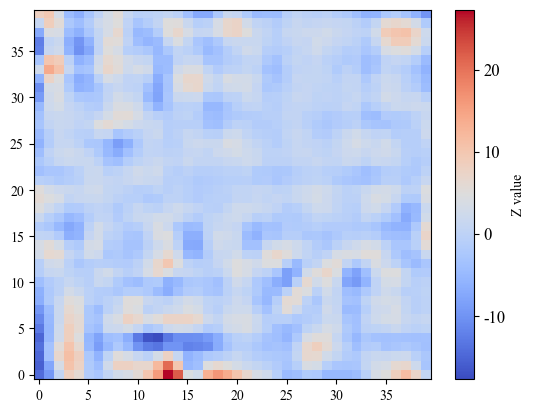

In [13]:
# plt.imshow(data_soomth[2]-data_soomth[1],cmap='coolwarm', aspect='auto', origin='lower')
# plt.imshow(data_soomth[0]-data_soomth[1],cmap='coolwarm', aspect='auto', origin='lower')
plt.imshow(data_soomth[0]-data_soomth[2],cmap='coolwarm', aspect='auto', origin='lower')
plt.colorbar(label='Z value').ax.tick_params(labelsize=font1['size']) # 显示颜色条

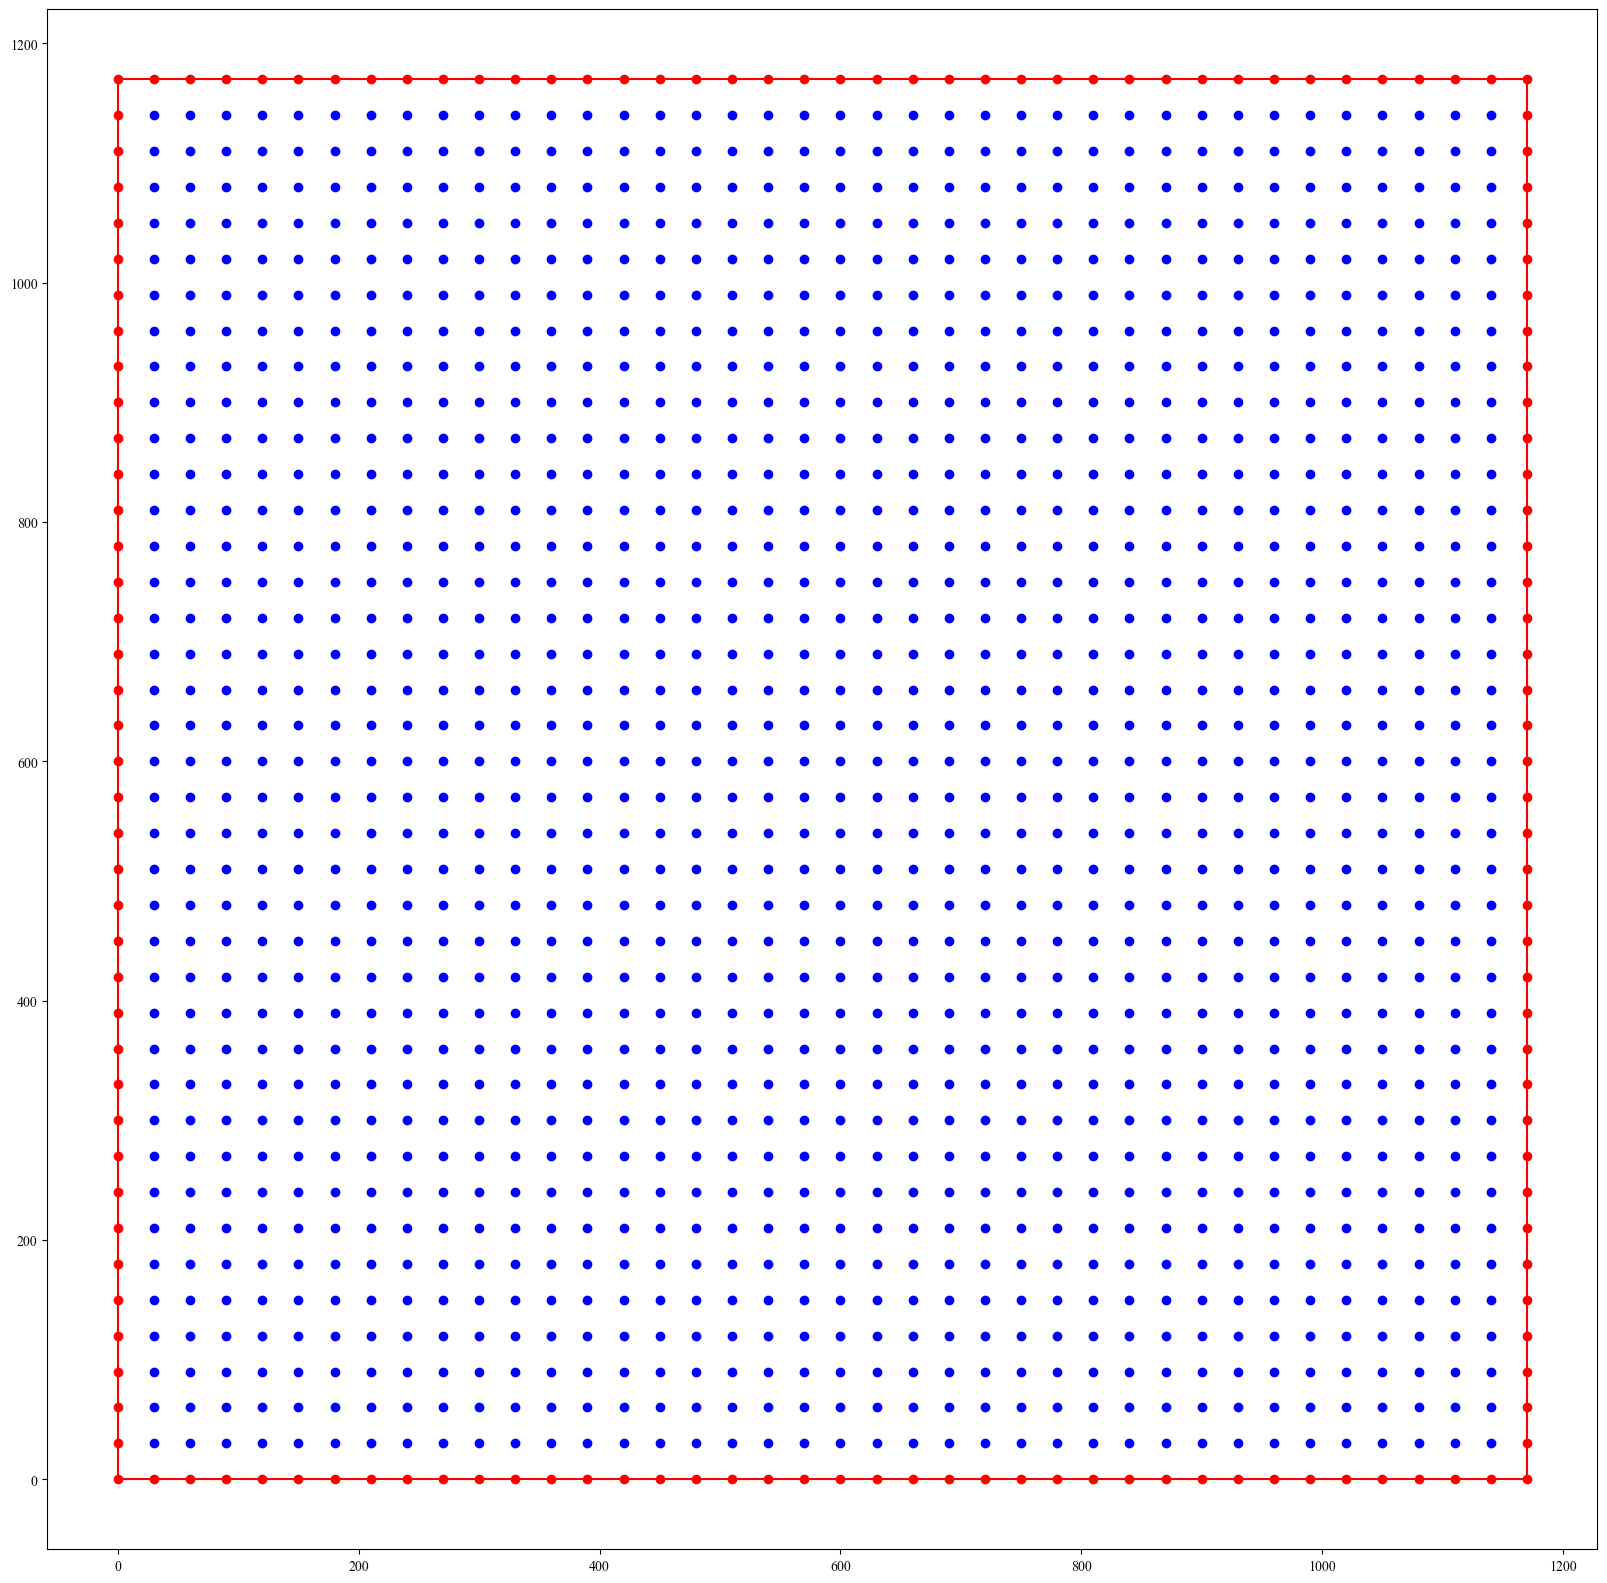

In [14]:
# Distinguish the internal points and external points
datafinal = np.array(data_wt)
n_row = datafinal.shape[0]

# 创建两个列表来存储内部点和边框点的坐标
internal_points = []
boundary_points = []

# 设置内部点和边框点的坐标
for i in range(n_row):
    for j in range(n_row):
        if i == 0 or i == n_row-1 or j == 0 or j == n_row-1:
            boundary_points.append(((i) * 30, (j) * 30))  # 添加边框点的实际距离坐标
        else:
            internal_points.append(((i) * 30, (j) * 30))  # 添加内部点的实际距离坐标

# 将列表转换为 NumPy 数组


points = boundary_points + internal_points
# 可视化矩阵
plt.figure(figsize=(20, 20))
plt.plot([0, 0, (n_row - 1) * 30, (n_row - 1) * 30, 0], 
         [0, (n_row - 1) * 30, (n_row - 1) * 30, 0, 0], 'r-')
for point in points:
    if point in boundary_points:
        plt.plot(point[0], point[1], 'ro')  # 绘制边界点
    else:
        plt.plot(point[0], point[1], 'bo')  # 绘制随机点



In [15]:
internal_points = np.array(internal_points)
boundary_points = np.array(boundary_points)
points = np.array(points)

start_time = time.perf_counter()



end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"The operation took {elapsed_time:.4f} seconds.")

The operation took 0.0000 seconds.


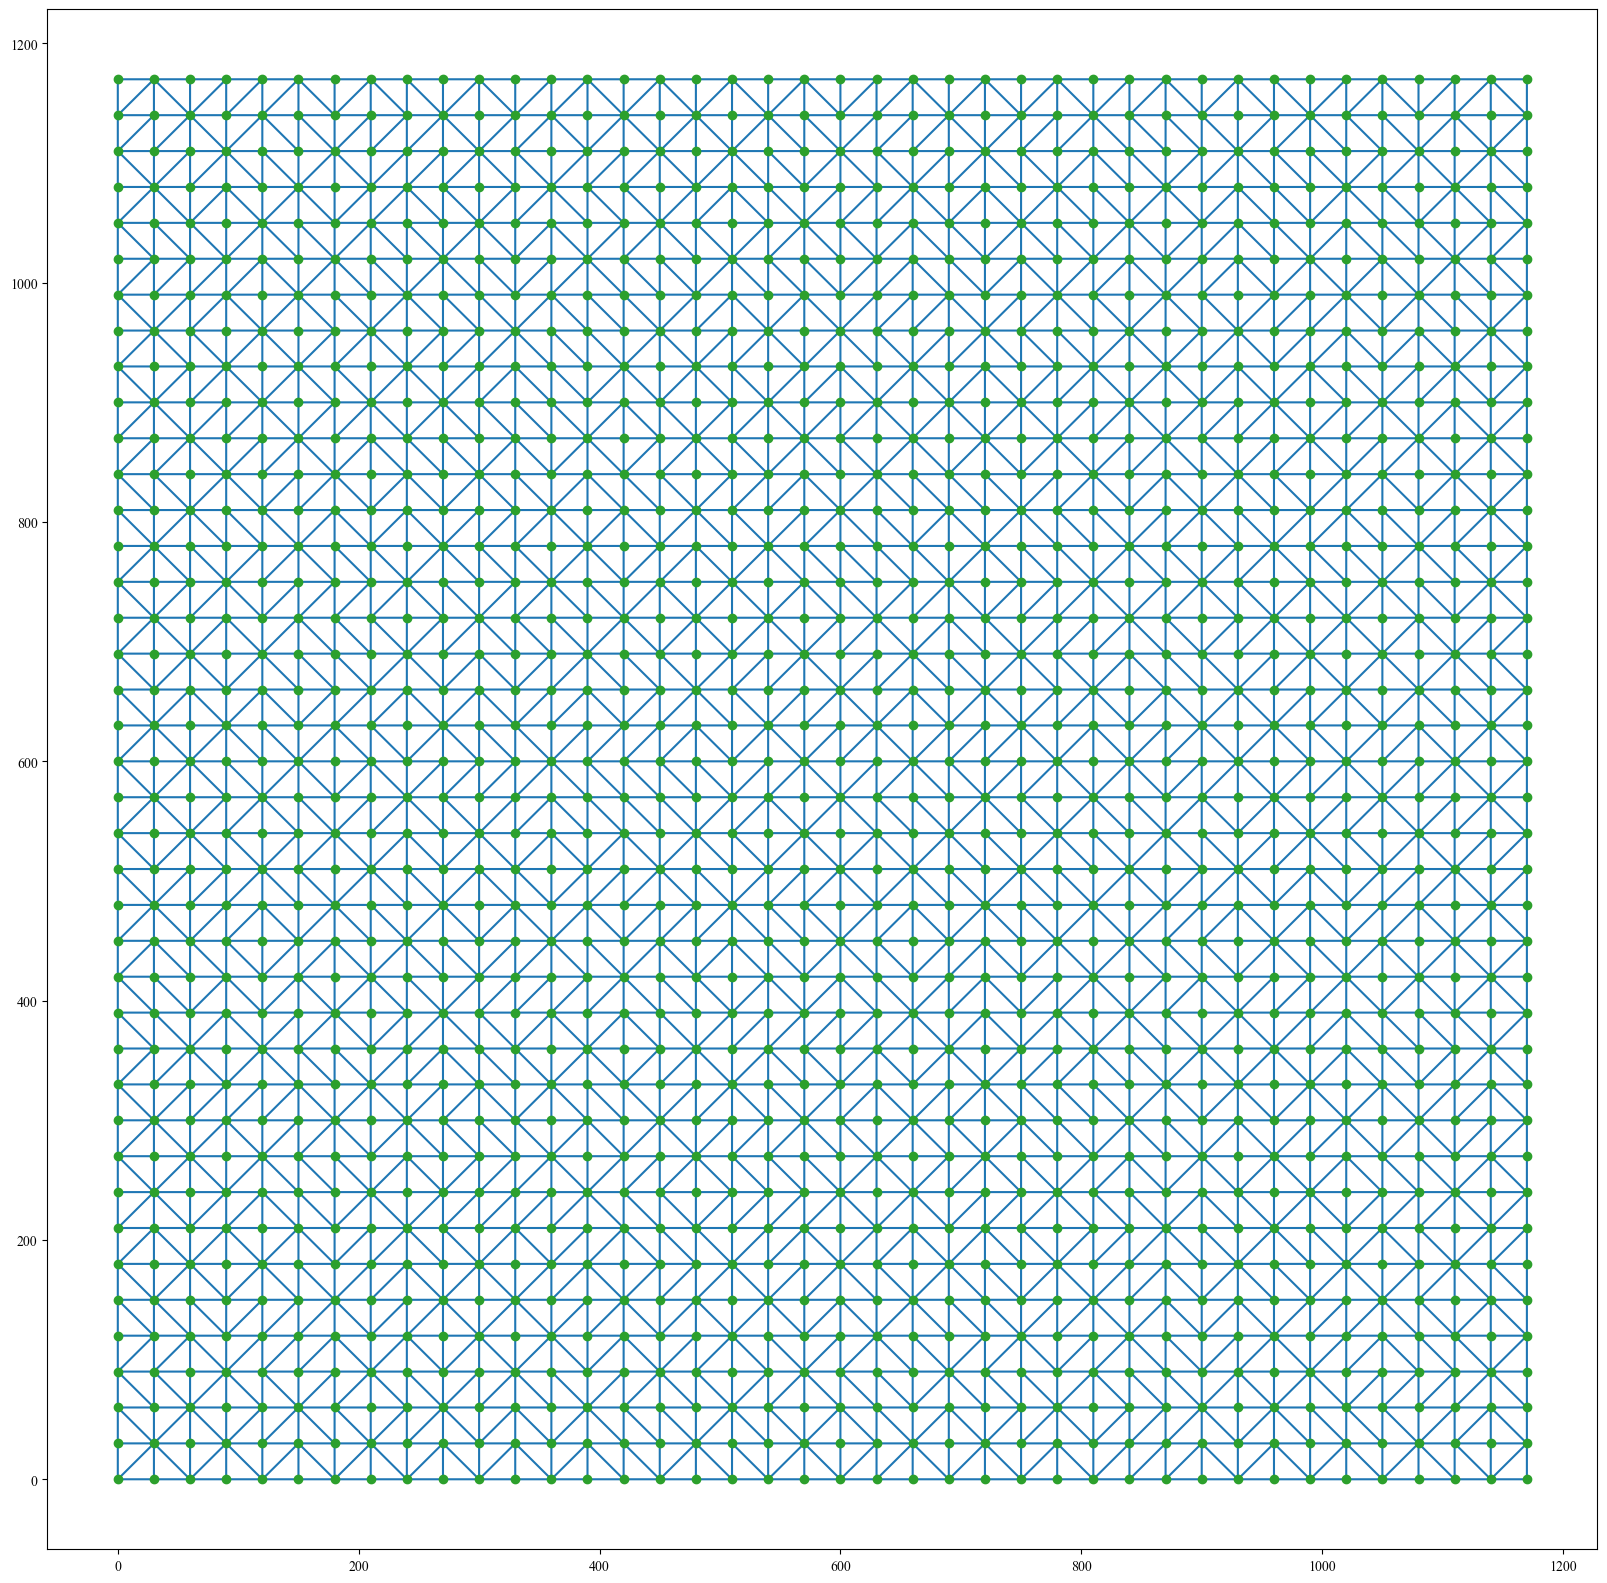

In [16]:

Inter = create_interpolator(datafinal, 30)
rho = create_rho(Inter)
tri = scipy.spatial.Delaunay(points)
plt.figure(figsize=(20, 20))
plt.triplot(points[:,0], points[:,1], tri.simplices)
plt.plot(points[:,0], points[:,1], 'o')
plt.show()

In [17]:
# test the func inter_king work well
z = Inter(10.5,15.2)#400
print(f"{z}")
print(f"Inter work well")

#test calculate_volume
p1=(15.6,20.3)
p2 = (40.6,20.3)
p3=(30.6,30.6)
z = calculate_volume(p1,p2,p3,rho)
print(f"{z}")
print(f"calculate_volume and rho work well")


# test Eopt
start_time = time.perf_counter()

Eoptr = Eopt(points,rho)
print("Origin Score: ",Eoptr)

end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"The operation took {elapsed_time:.4f} seconds.")
print(f"Eopt work well")

(array(1156.76866667), 1163)
Inter work well
140921.1929349254
calculate_volume and rho work well
Origin Score:  4413309401.299446
The operation took 0.2993 seconds.
Eopt work well


In [18]:
n_iterations = 300
n_particles = 30

n_internal_points = internal_points.shape[0]
n_boundary_points = boundary_points.shape[0]
fixed_points = boundary_points.shape[0]
n_points = internal_points.shape[0]

# debug! change the x_range
x_range = (-5, 5)
v_max = (x_range[1] - x_range[0]) * 0.2
c1 = 1  # 认知因子
c2 = 1  # 社会因子
w = 0.3  # 惯性权重

particles = (np.random.rand(n_particles, internal_points.shape[0], 2) * 10 - 5) + internal_points
fixed_points_expanded = np.tile(boundary_points, (n_particles, 1, 1))
combined_points = np.concatenate((particles, fixed_points_expanded), axis=1)

velocities = np.zeros((n_particles, n_points + fixed_points, 2))

pbest_positions = combined_points.copy()

start_time = time.perf_counter()
pbest_scores = np.array([Eopt(p, rho) for p in combined_points])
end_time = time.perf_counter()
elapsed_time = end_time - start_time
print(f"The operation took {elapsed_time:.4f} seconds.")

gbest_position = pbest_positions[np.argmin(pbest_scores)]
gbest_score = np.min(pbest_scores)





The operation took 25.6795 seconds.


Iteration 1/300, Best Score: 4218250224.030011
The operation took 27.6621 seconds.
Iteration 2/300, Best Score: 4134966557.9881887
The operation took 27.3969 seconds.
Iteration 3/300, Best Score: 4095014927.694349
The operation took 27.4706 seconds.
Iteration 4/300, Best Score: 4075251124.9735584
The operation took 27.6518 seconds.
Iteration 5/300, Best Score: 4068459855.7883377
The operation took 27.1960 seconds.
Iteration 6/300, Best Score: 4063129066.625786
The operation took 27.2948 seconds.
Iteration 7/300, Best Score: 4057034548.6115994
The operation took 27.2802 seconds.
Iteration 8/300, Best Score: 4052604569.5354424
The operation took 27.1641 seconds.
Iteration 9/300, Best Score: 4047230678.3623633
The operation took 27.5575 seconds.
Iteration 10/300, Best Score: 4042910670.3491473
The operation took 27.1355 seconds.
Iteration 11/300, Best Score: 4040983007.1191072
The operation took 27.1688 seconds.
Iteration 12/300, Best Score: 4038752326.862067
The operation took 27.1535 se

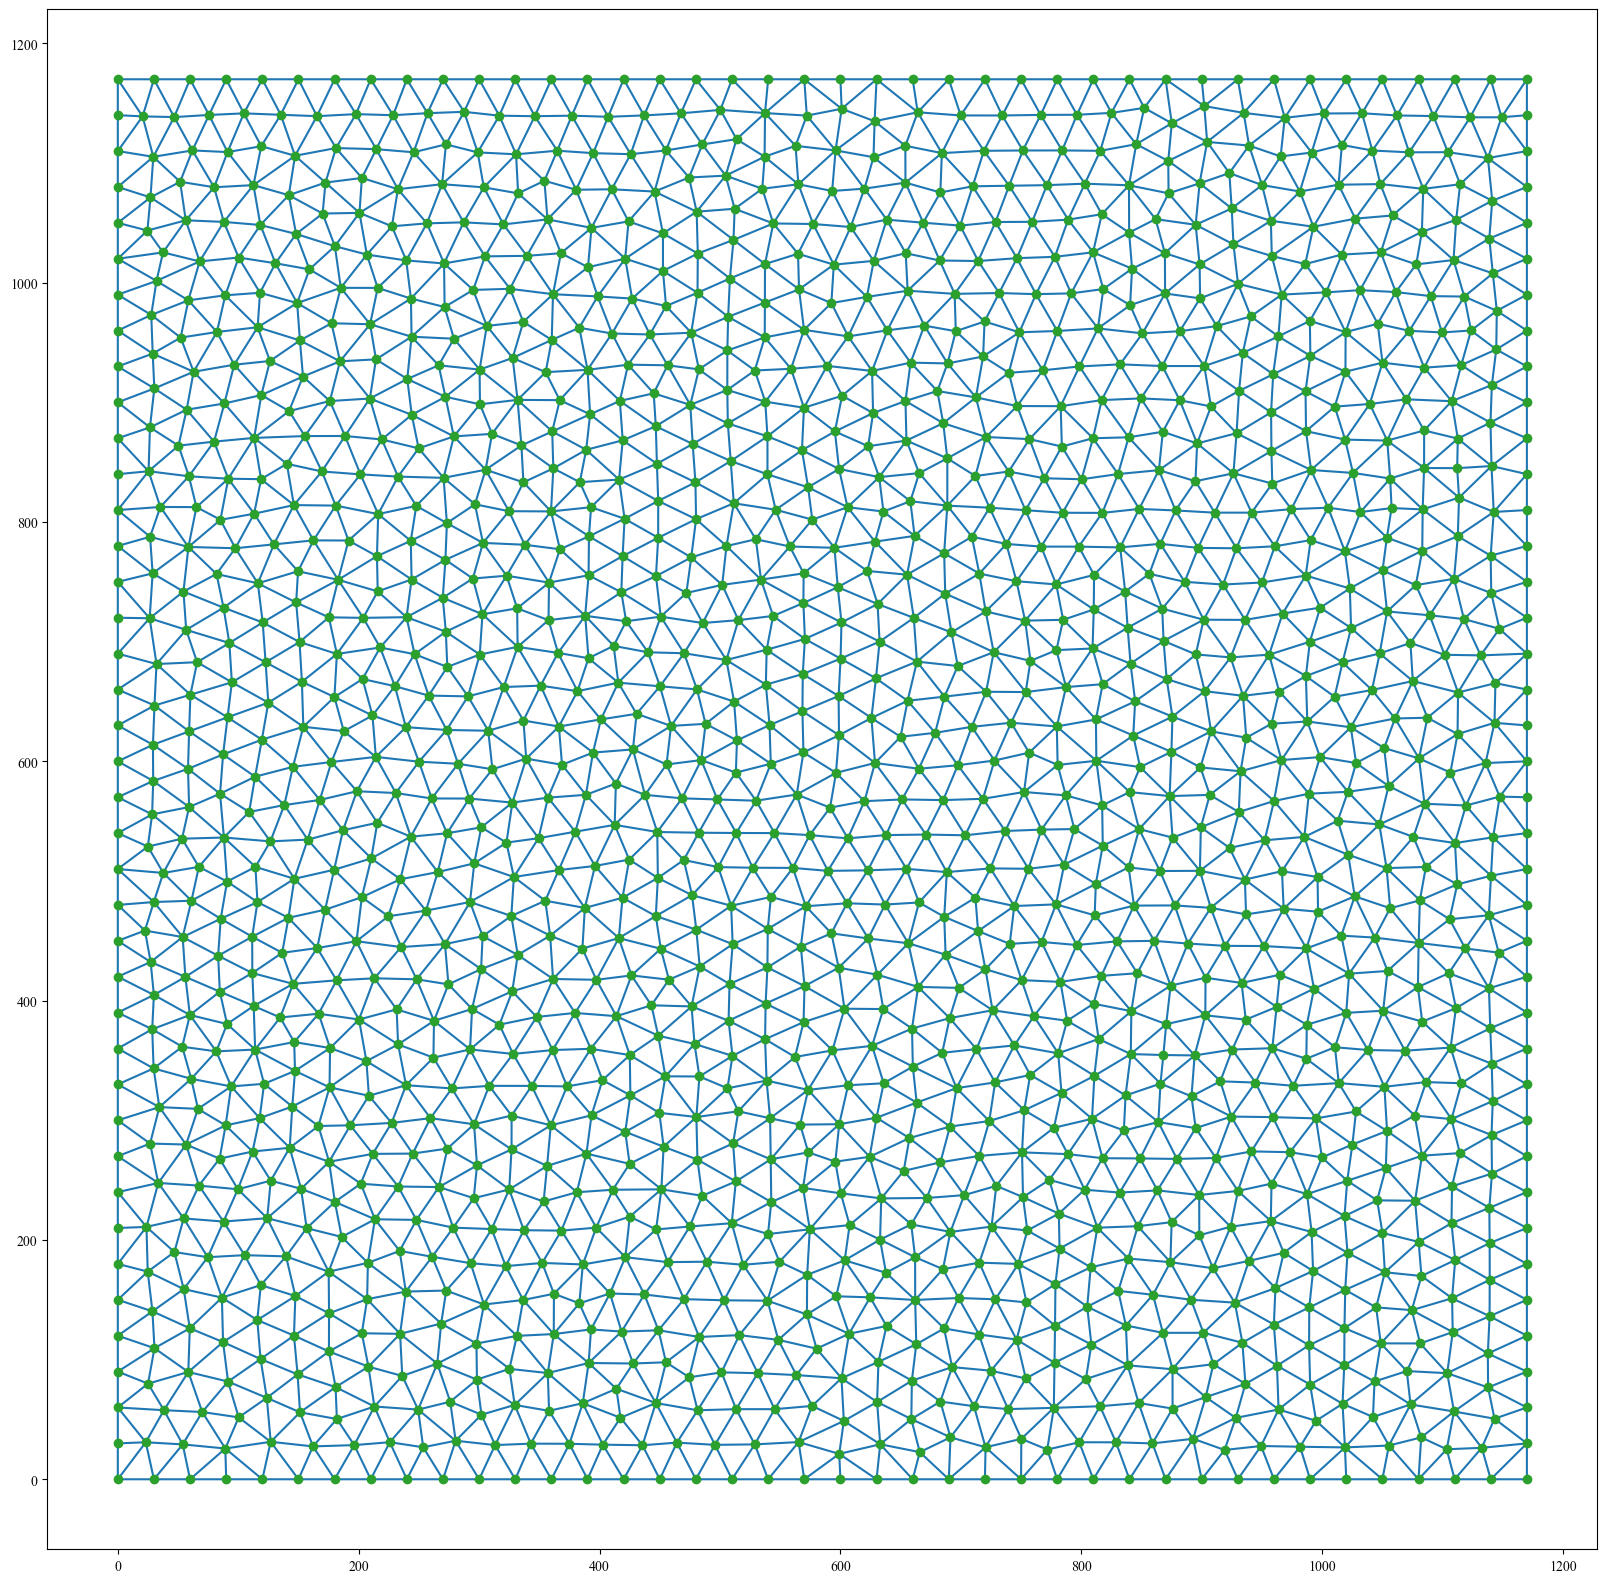

In [19]:
EOPTS = []
vvv=[]
vv=[]

for i in range(n_iterations):
    c3 = 5-5*(1/(1+math.exp(-(i-n_iterations/3))))

    start_time = time.perf_counter()
    tri = scipy.spatial.Delaunay(gbest_position)
    # plt.triplot(gbest_position[:,0],gbest_position[:,1], tri.simplices)
    # plt.plot(gbest_position[:,0], gbest_position[:,1], 'o')
    # plt.show()
    
    ring_neighbors = find_all_triangles_in_one_ring(tri)
    new_positions = np.copy(gbest_position)
    
    for h in range(n_points):
        total_area = 0
        weighted_positions = np.zeros(2)
        
        for simplex in ring_neighbors[h]:
            A, B, C = tri.points[tri.simplices[simplex]]
            center = circumcenter(A, B, C)
            area = triangle_area(A, B, C)*rho(A,B,C)
            total_area += area
            weighted_positions += center * area
            
        if total_area > 0:
            new_positions[h] = weighted_positions / total_area
  
    for j in range(n_particles):

  
        r1 = np.random.random((n_points + fixed_points, 2))
        r2 = np.random.random((n_points + fixed_points, 2))
        r3 = np.random.random((n_points + fixed_points, 2))  # 几何调整的随机因子
        # 更新速度
        velocities[j] = (w * velocities[j] +
                         c1 * r1 * (pbest_positions[j] - combined_points[j]) +
                         c2 * r2 * (gbest_position - combined_points[j]))
        velocities[j] += c3 * r3 * (new_positions - combined_points[j])
        velocities[j] = np.clip(velocities[j], -v_max, v_max)  # 限制速度
        vv.append(velocities[j])
        # 更新位置（仅更新可变点部分）
        combined_points[j, :n_points] += velocities[j, :n_points]
        

        # 评估新的位置
        current_score = Eopt(combined_points[j],rho)
        
        # 更新个体最优
        if current_score < pbest_scores[j]:
            pbest_scores[j] = current_score
            pbest_positions[j] = combined_points[j].copy()

        # 更新全局最优
        if current_score < gbest_score:
            gbest_score = current_score
            gbest_position = combined_points[j].copy()


    
    print(f"Iteration {i+1}/{n_iterations}, Best Score: {gbest_score}")
    EOPTS.append(gbest_score)
    vvv.append(vv)

    
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"The operation took {elapsed_time:.4f} seconds.")
# print("Best Position:", gbest_position)
tri = scipy.spatial.Delaunay(gbest_position)
plt.figure(figsize=(20, 20))
plt.triplot(gbest_position[:,0],gbest_position[:,1], tri.simplices)
plt.plot(gbest_position[:,0], gbest_position[:,1], 'o')
plt.show()

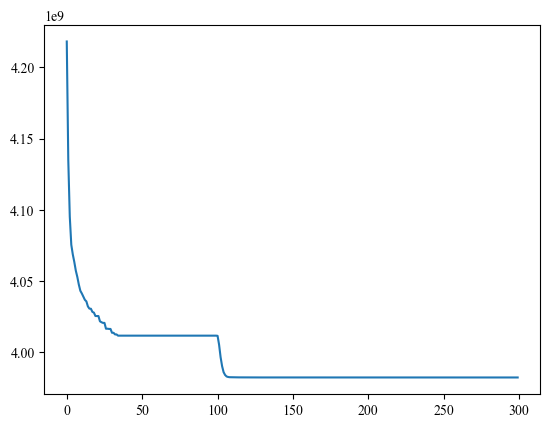

In [20]:
plt.plot(EOPTS)

In [21]:
# test the func inter_king work well
z = Inter(21,479)#400
print(f"{z}")
print(f"Inter work well")

(array(1171.40666667), 1166)
Inter work well


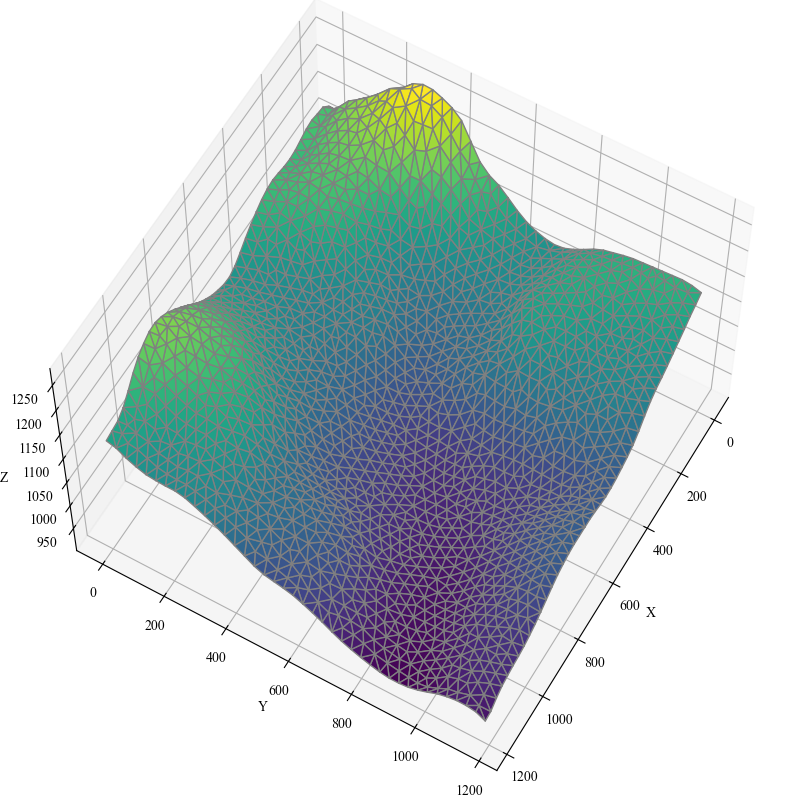

In [22]:
# tri.simplices 的形状为 (num_triangles, 3)
coordinates_3d = np.zeros((gbest_position.shape[0], 3))
for i, (target_x, target_y) in enumerate(gbest_position):
    z = Inter(target_x, target_y)
    coordinates_3d[i] = [target_x, target_y, z[0]]

# Convert the ndarray to a DataFrame
df = pd.DataFrame(coordinates_3d)

# Save the DataFrame to an Excel file
file_path = 'coordinates_3d.xlsx'
df.to_excel(file_path, index=False)


plotpoints = coordinates_3d
x = plotpoints[:, 0]
y = plotpoints[:, 1]
z = plotpoints[:, 2]
ptri = scipy.spatial.Delaunay(plotpoints[:, :2])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制三角面
ax.plot_trisurf(x, y, z, triangles=ptri.simplices, cmap='viridis', edgecolor='gray')

# 设置轴标签（保留标尺）
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 设置视角，从 Y 轴看
ax.view_init(elev=60, azim=30)

# 显示图形
plt.show()

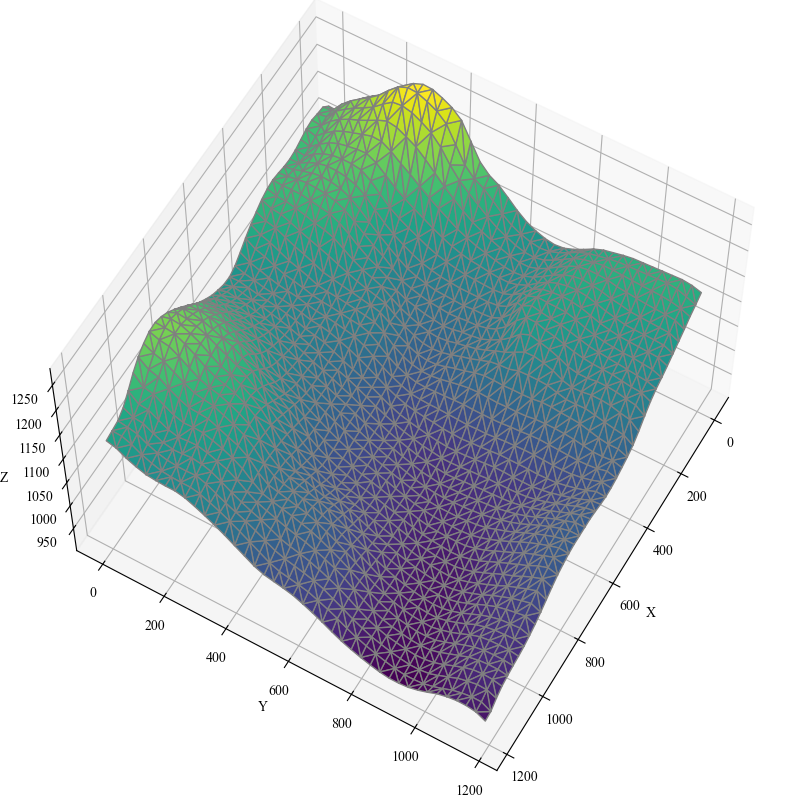

In [23]:
coordinates_3d = np.zeros((points.shape[0], 3))
for i, (target_x, target_y) in enumerate(points):
    z = Inter(target_x, target_y)
    coordinates_3d[i] = [target_x, target_y, z[0]]



# Convert the ndarray to a DataFrame
df = pd.DataFrame(coordinates_3d)

# Save the DataFrame to an Excel file
file_path = 'points.xlsx'
df.to_excel(file_path, index=False)




plotpoints = coordinates_3d
x = plotpoints[:, 0]
y = plotpoints[:, 1]
z = plotpoints[:, 2]
ptri = scipy.spatial.Delaunay(plotpoints[:, :2])

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# 绘制三角面
ax.plot_trisurf(x, y, z, triangles=ptri.simplices, cmap='viridis', edgecolor='gray')

# 设置轴标签（保留标尺）
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# 设置视角，从 Y 轴看
ax.view_init(elev=60, azim=30)

# 显示图形
plt.show()

In [24]:
filename = "POS_Eopt_200.csv"

with open(filename, mode='w', newline='') as file:
    # 创建CSV写入器
    writer = csv.writer(file)
    
    # 写入数字，每个数字一行
    for number in EOPTS:
        writer.writerow([number])

print("数据已经保存到CSV文件。")

数据已经保存到CSV文件。
